In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
import osmnx as ox

In [3]:
os.chdir("..")

In [4]:
gdf_with_inclination = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")
gdf_without_inclination = gpd.read_parquet(
    "results/hexagon_grid_bamberg_without_inclination.parquet"
)

In [5]:
for column in list(gdf_with_inclination.columns)[1:]:
    for gdf in [gdf_with_inclination, gdf_without_inclination]:
        gdf[column] = gdf[column].apply(lambda x: np.mean(list(x.values())))

In [6]:
gdf_with_inclination.head(1)

,geometry,average_time_bike_1,average_time_bike_2,average_time_bike_20,average_time_bike_morning_vuln1_1,average_time_bike_morning_vuln1_2,average_time_bike_morning_vuln1_20,average_time_bike_morning_vuln2_1,average_time_bike_morning_vuln2_2,average_time_bike_morning_vuln2_20,...,average_time_walk_PT_evening_vuln2_20,average_time_walk_PT_evening_vuln3_1,average_time_walk_PT_evening_vuln3_2,average_time_walk_PT_evening_vuln3_20,average_time_walk_PT_evening_vuln4_1,average_time_walk_PT_evening_vuln4_2,average_time_walk_PT_evening_vuln4_20,average_time_walk_PT_evening_vuln5_1,average_time_walk_PT_evening_vuln5_2,average_time_walk_PT_evening_vuln5_20
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...",6.661755,7.194323,10.657284,7.856956,8.34224,13.28535,8.98368,9.418548,15.428905,...,51.806087,38.378771,39.753045,56.48391,41.338498,42.968262,60.467604,43.528243,45.444253,64.01607


In [7]:
gdf_without_inclination.head(1)

,geometry,average_time_bike_1,average_time_bike_2,average_time_bike_20,average_time_bike_morning_vuln1_1,average_time_bike_morning_vuln1_2,average_time_bike_morning_vuln1_20,average_time_bike_morning_vuln2_1,average_time_bike_morning_vuln2_2,average_time_bike_morning_vuln2_20,...,average_time_walk_PT_evening_vuln2_20,average_time_walk_PT_evening_vuln3_1,average_time_walk_PT_evening_vuln3_2,average_time_walk_PT_evening_vuln3_20,average_time_walk_PT_evening_vuln4_1,average_time_walk_PT_evening_vuln4_2,average_time_walk_PT_evening_vuln4_20,average_time_walk_PT_evening_vuln5_1,average_time_walk_PT_evening_vuln5_2,average_time_walk_PT_evening_vuln5_20
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...",5.934332,6.325049,9.425678,7.24508,7.582317,11.898947,8.20377,8.519647,13.728268,...,51.880346,38.897114,40.231645,56.525694,41.643083,43.269259,60.425277,43.830113,45.730714,63.93534


In [8]:
configurations = [
    "average_time_walk_morning_vuln5_20",
    "average_time_walk_PT_afternoon_vuln3_2",
    "average_time_walk_20",
    "average_time_bike_morning_vuln1_1",
    "average_time_walk_PT_morning_vuln2_2",
]

In [9]:
result = {}
for column in configurations:
    result[column] = {
        "mean_with_inclination": gdf_with_inclination[column].mean(),
        "std_with_inclination": gdf_with_inclination[column].std(),
        "median_with_inclination": gdf_with_inclination[column].median(),
        "mean_without_inclination": gdf_without_inclination[column].mean(),
        "std_without_inclination": gdf_without_inclination[column].std(),
        "median_without_inclination": gdf_without_inclination[column].median(),
    }

In [10]:
df = pd.DataFrame(result)
df

,average_time_walk_morning_vuln5_20,average_time_walk_PT_afternoon_vuln3_2,average_time_walk_20,average_time_bike_morning_vuln1_1,average_time_walk_PT_morning_vuln2_2
mean_with_inclination,82.772303,32.359499,21.014032,4.624476,25.701868
std_with_inclination,59.579438,23.757374,13.094996,3.681097,18.565757
median_with_inclination,67.526033,25.643835,18.144553,3.516759,20.714362
mean_without_inclination,82.598269,32.287772,20.964332,4.387786,25.645677
std_without_inclination,59.536860,23.725081,13.081633,3.602477,18.542152
median_without_inclination,67.486601,25.623553,17.967520,3.333923,20.669950


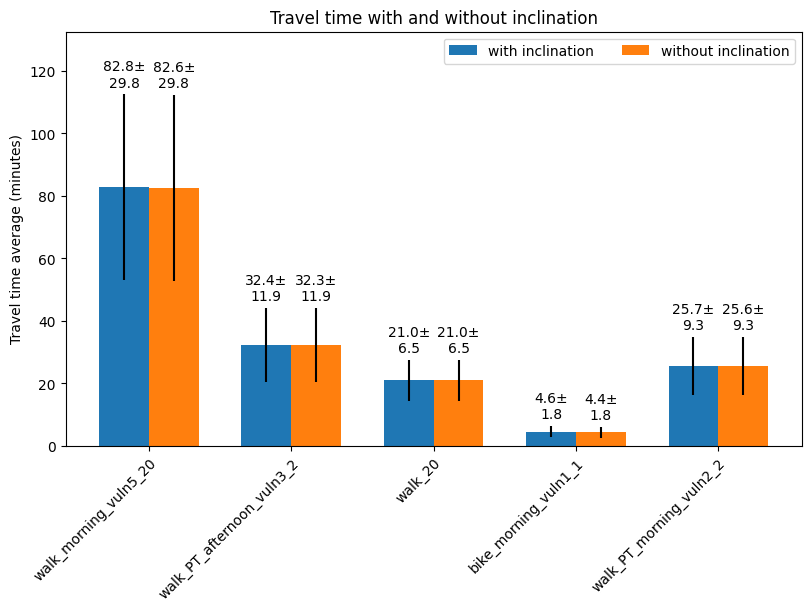

In [11]:
n_s = {
    "with inclination": df.loc["mean_with_inclination"],
    "without inclination": df.loc["mean_without_inclination"],
}
standard_deviations = {
    "with inclination": df.loc["std_with_inclination"],
    "without inclination": df.loc["std_without_inclination"],
}

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.7  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(8, 6))


max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement, 1)
    y_errs = np.array(standard_deviations.get(attribute)) / 2

    max_value = max(max_value, max(measurement) + max(y_errs))
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, yerr=y_errs)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}±\n{err:.1f}" for val, err in zip(measurement, y_errs)],
        padding=3,
    )
    multiplier += 1

ax.set_ylabel("Travel time average (minutes)")
ax.set_title("Travel time with and without inclination")
ax.set_xticks(
    x + width / 2,
    [configuration.replace("average_time_", "") for configuration in configurations],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)
ax.legend(loc="upper right", ncols=2)
ax.set_ylim(0, max_value + 20)

plt.show()

In [64]:
G_walk_with_inclination = pickle.load(
    open("results/walk.p", "rb")
)

G_walk_without_inclination = pickle.load(
    open("results/walk_without_inclination.p", "rb")
)

G_bike_with_inclination = pickle.load(
    open("results/bike.p", "rb")
)

G_bike_without_inclination = pickle.load(
    open("results/bike_without_inclination.p", "rb")
)

In [65]:
gdf_edges_walk_with_inclination = ox.graph_to_gdfs(G_walk_with_inclination, nodes=False)
gdf_edges_walk_without_inclination = ox.graph_to_gdfs(G_walk_without_inclination, nodes=False)

gdf_edges_bike_with_inclination = ox.graph_to_gdfs(G_bike_with_inclination, nodes=False)
gdf_edges_bike_without_inclination = ox.graph_to_gdfs(G_bike_without_inclination, nodes=False)

In [15]:
(gdf_edges_walk_with_inclination["time"] - gdf_edges_walk_without_inclination["time"]).abs().describe()

count    30613.000000
mean         0.011040
std          0.035561
min          0.000000
25%          0.000000
50%          0.000000
75%          0.001931
max          0.694911
Name: time, dtype: float64

In [16]:
(gdf_edges_walk_with_inclination["time_afternoon_vuln1"] - gdf_edges_walk_without_inclination["time_afternoon_vuln1"]).abs().describe()

count    30613.000000
mean         0.017910
std          0.055987
min          0.000000
25%          0.000000
50%          0.000000
75%          0.003220
max          1.389822
Name: time_afternoon_vuln1, dtype: float64

In [17]:
gdf_hexagon_grid_bamberg = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")
gdf_hexagon_grid_bamberg_without_inclination = gpd.read_parquet(
    "results/hexagon_grid_bamberg_without_inclination.parquet"
)

In [19]:
for column in gdf_hexagon_grid_bamberg.columns[1:]:
    gdf_hexagon_grid_bamberg[column] = gdf_hexagon_grid_bamberg[column].apply(
        lambda x: np.mean(list(x.values()))
    )
    gdf_hexagon_grid_bamberg_without_inclination[column] = gdf_hexagon_grid_bamberg_without_inclination[column].apply(
        lambda x: np.mean(list(x.values()))
    )

In [21]:
gdf_hexagon_grid_bamberg = gdf_hexagon_grid_bamberg.drop(columns=["geometry"])
gdf_hexagon_grid_bamberg_without_inclination = gdf_hexagon_grid_bamberg_without_inclination.drop(columns=["geometry"])

In [62]:
interesting_edges = [(1458490248, 454971116, 0), (258878833, 258878816, 0), (309742277, 309742829, 0), (1449435180, 30585155, 0), (1482460447, 3751473901, 0)]

In [73]:
gdf_walk_without_incl_filtered = gdf_edges_walk_without_inclination[gdf_edges_walk_without_inclination.index.isin(interesting_edges)][["time", "inclination_percentage"]].rename(columns={"time": "time_walk_without_inclination"})
gdf_walk_with_incl_filtered = gdf_edges_walk_with_inclination[gdf_edges_walk_with_inclination.index.isin(interesting_edges)][["time"]].rename(columns={"time": "time_walk_with_inclination"})
gdf_bike_without_incl_filtered = gdf_edges_bike_without_inclination[gdf_edges_bike_without_inclination.index.isin(interesting_edges)][["time"]].rename(columns={"time": "time_bike_without_inclination"})
gdf_bike_with_incl_filtered = gdf_edges_bike_with_inclination[gdf_edges_bike_with_inclination.index.isin(interesting_edges)][["time"]].rename(columns={"time": "time_bike_with_inclination"})

In [86]:
df_concat = pd.concat([
    gdf_walk_without_incl_filtered,
    gdf_walk_with_incl_filtered,
    gdf_bike_without_incl_filtered,
    gdf_bike_with_incl_filtered,
], axis=1)
df_concat

,,,time_walk_without_inclination,inclination_percentage,time_walk_with_inclination,time_bike_without_inclination,time_bike_with_inclination
u,v,key,,,,,
1458490248,454971116,0,0.602517,0.159777,0.733975,0.133671,0.733975
1449435180,30585155,0,0.924409,0.013186,0.924409,0.205084,0.219971
258878833,258878816,0,0.807017,0.243819,0.983094,0.179040,0.983094
309742277,309742829,0,0.564337,0.183150,0.687465,0.125201,0.687465
1482460447,3751473901,0,2.248324,-0.083202,2.151967,0.498800,0.374868


In [91]:
df_concat[sorted(list(df_concat.columns))]

,,,inclination_percentage,time_bike_with_inclination,time_bike_without_inclination,time_walk_with_inclination,time_walk_without_inclination
u,v,key,,,,,
1458490248,454971116,0,0.159777,0.733975,0.133671,0.733975,0.602517
1449435180,30585155,0,0.013186,0.219971,0.205084,0.924409,0.924409
258878833,258878816,0,0.243819,0.983094,0.179040,0.983094,0.807017
309742277,309742829,0,0.183150,0.687465,0.125201,0.687465,0.564337
1482460447,3751473901,0,-0.083202,0.374868,0.498800,2.151967,2.248324
